# ĐỒ ÁN 2: DATA FITTING VÀ PHƯƠNG PHÁP OLS
## PHẦN 2: ỨNG DỤNG HỒI QUY VÀO BỘ DỮ LIỆU THỰC TẾ (VIDEO GAMES SALES)







In [1]:
# Lê Phạm Đăng Khiêm

# Setup libraries and paths for Part 2
%pip install statsmodels
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV

PROJECT_DIR = Path.cwd().resolve()
for candidate in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (candidate / "part2" / "data_pipeline.py").exists():
        PROJECT_DIR = candidate
        break
else:
    raise FileNotFoundError("Không tìm thấy thư mục part2 của đồ án.")

PART2_DIR = PROJECT_DIR / "part2"
DATA_CSV = PART2_DIR / "data" / "video_games_sales.csv"
if str(PART2_DIR) not in sys.path:
    sys.path.insert(0, str(PART2_DIR))

from data_pipeline import DataPipeline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8)

print("[*] Da tai thanh cong thu vien va cau hinh do hoa!")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*] Da tai thanh cong thu vien va cau hinh do hoa!


---
### 1. Phân tích Dữ liệu Khám phá (EDA)
Khảo sát tổng quan sự phân phối của doanh số bán hàng, mối liên hệ tương quan tuyến tính giữa các chỉ số điểm số và các biến đặc trưng khác để định hình hướng tiếp cận xây dựng mô hình hồi quy.

Đang load dữ liệu...
Đang tiền xử lý sơ bộ...

--- Đang vẽ Biểu đồ 1: Heatmap tương quan ---
Tỷ lệ dữ liệu khuyết (%) ở các biến số:
 User_Count         54.602548
User_Score         54.602548
Critic_Count       51.330821
Critic_Score       51.330821
Year_of_Release     1.608948
dtype: float64


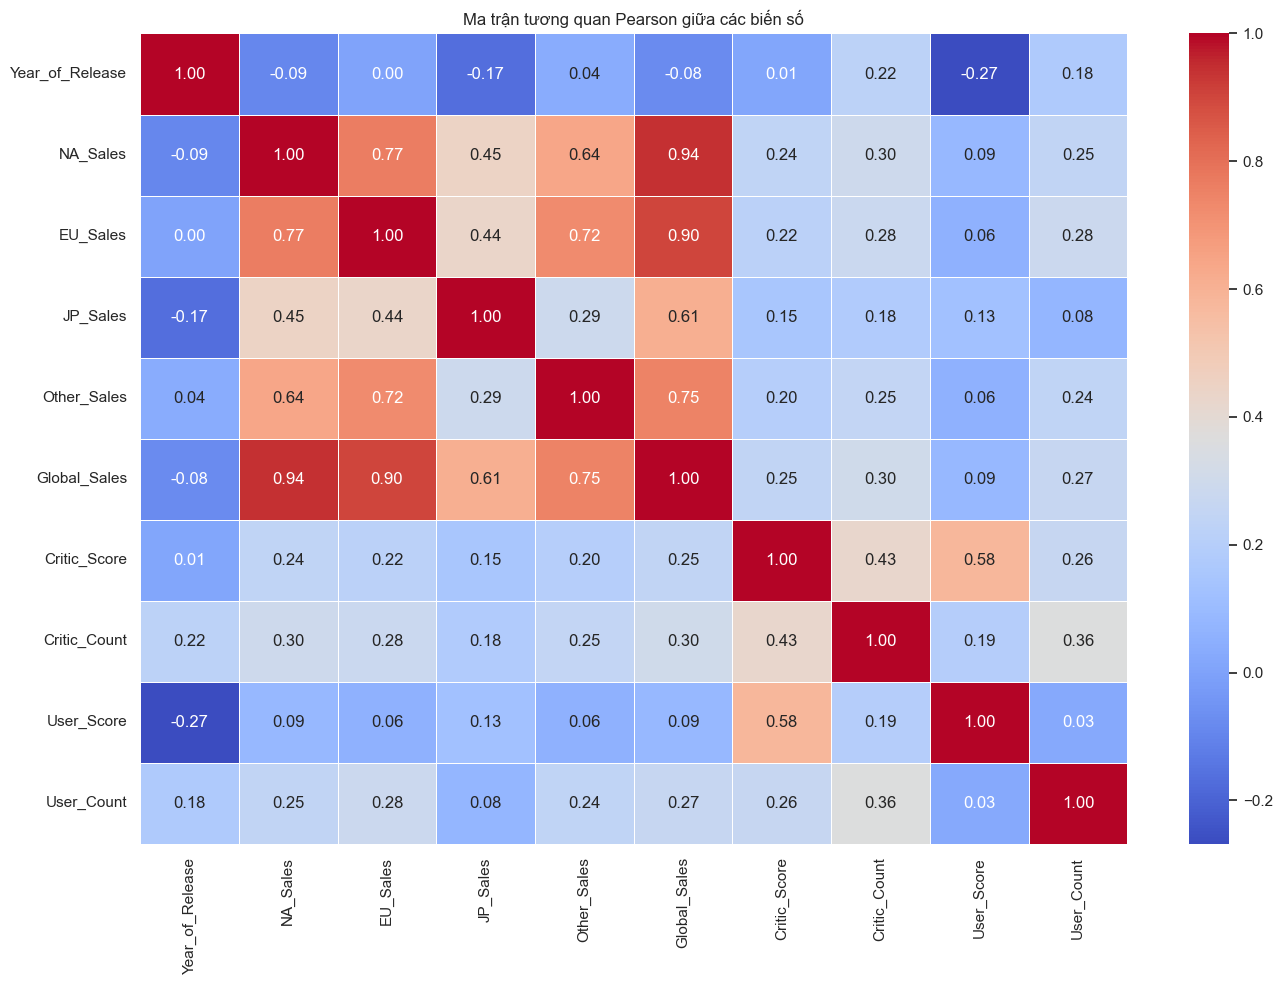


--- Đang vẽ Biểu đồ 2: Boxplot Global_Sales theo Genre ---


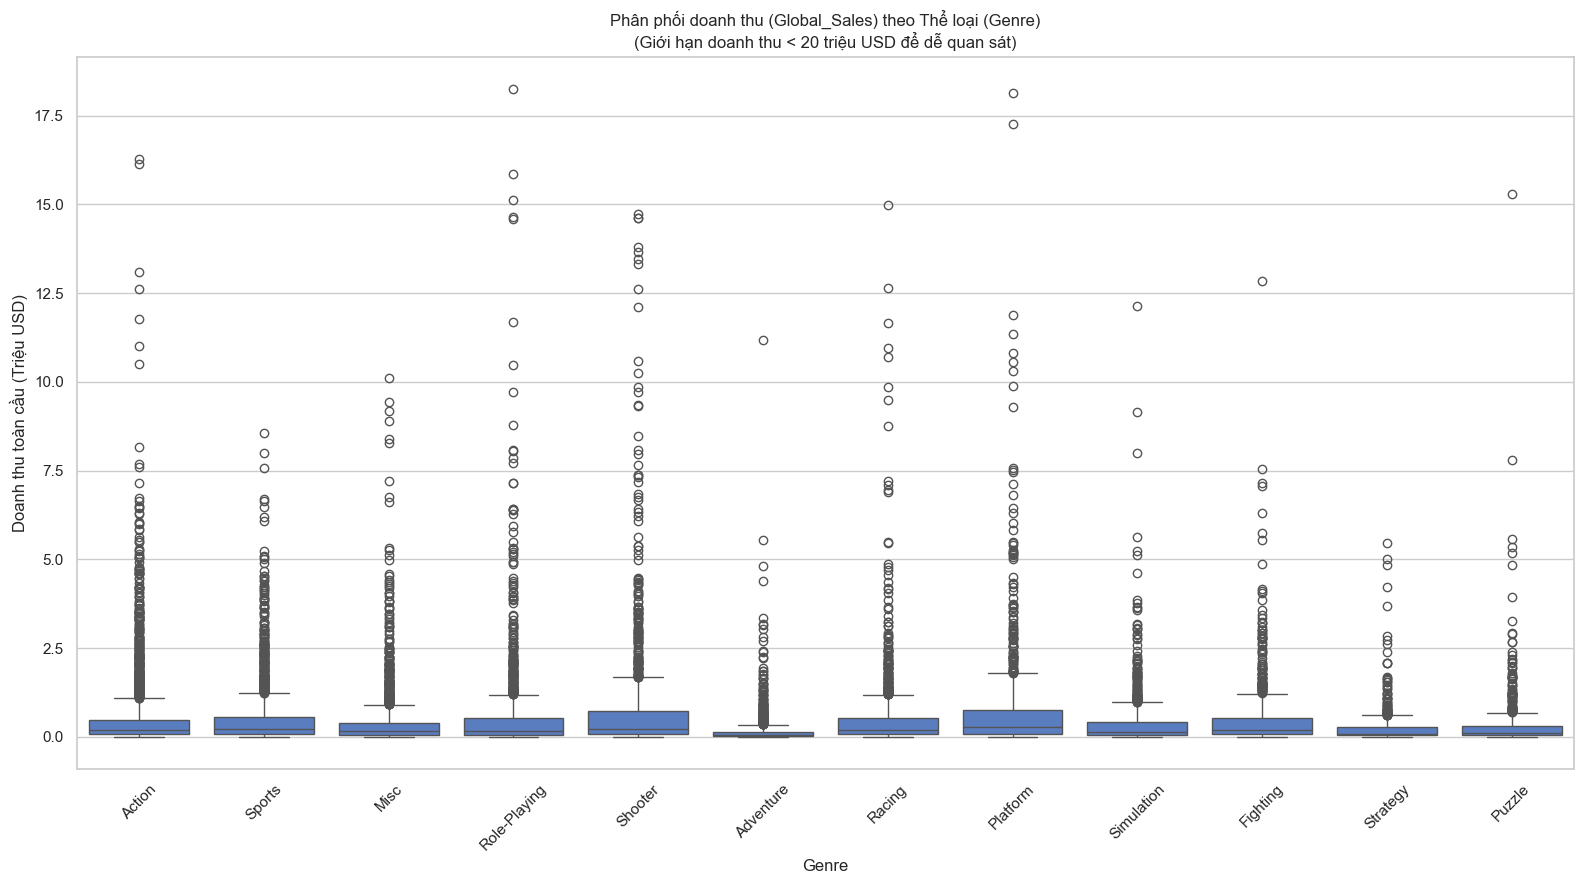


--- Đang vẽ Biểu đồ 3: Scatter plot Critic_Score vs Global_Sales ---


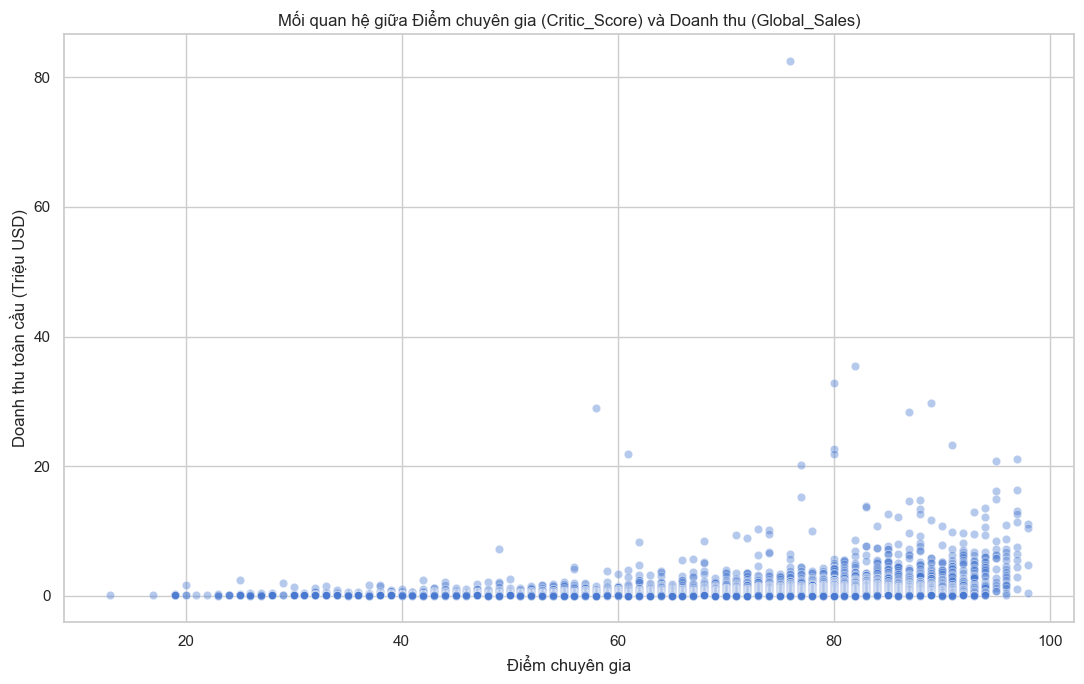


--- Đang vẽ Biểu đồ 4: Histogram phân phối Critic_Score ---


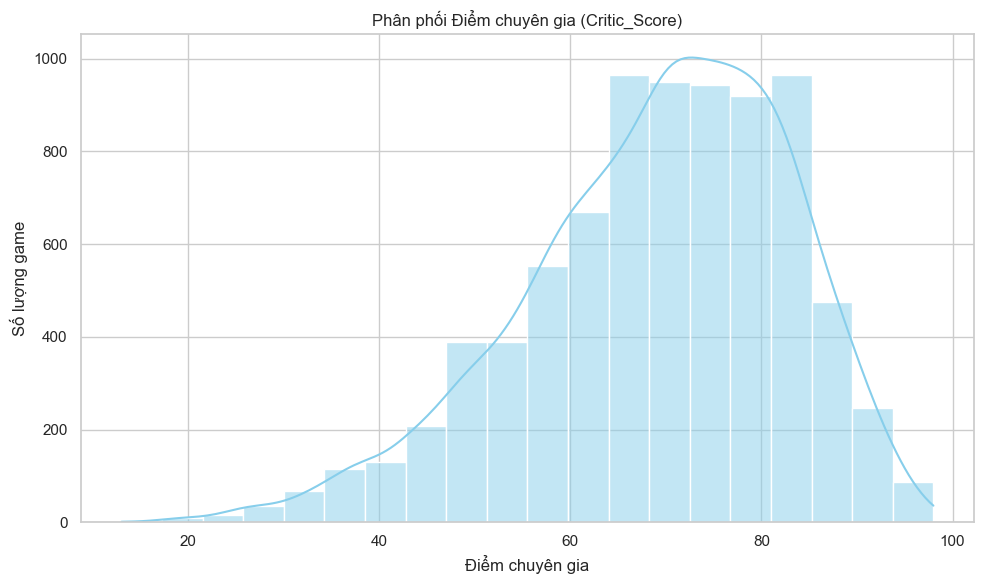


--- Đã chạy xong EDA! ---


In [2]:
# Trần Thanh Nam

import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from pathlib import Path
import sys

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

PROJECT_DIR = Path.cwd().resolve()
for candidate in [PROJECT_DIR, *PROJECT_DIR.parents]:
    if (candidate / "part2" / "data" / "video_games_sales.csv").exists():
        PROJECT_DIR = candidate
        break
else:
    raise FileNotFoundError("Không tìm thấy thư mục part2 của đồ án.")
DATA_CSV = PROJECT_DIR / "part2" / "data" / "video_games_sales.csv"
REPORT_IMAGE_DIR = PROJECT_DIR / "report" / "images_nam"
REPORT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def save_report_figure(filename):
    output_path = REPORT_IMAGE_DIR / filename
    if output_path.exists():
        output_path.unlink()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# Setup style vẽ biểu đồ cho đẹp và đồng nhất
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 8) # Kích thước mặc định cho các biểu đồ

# --- 1. LOAD DỮ LIỆU ---
print("Đang load dữ liệu...")
df = pd.read_csv(DATA_CSV)

# --- 2. TIỀN XỬ LÝ DỮ LIỆU SƠ BỘ ---
print("Đang tiền xử lý sơ bộ...")
# Ép kiểu User_Score, chuyển 'tbd' và các lỗi khác thành NaN để tính toán được
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')

# --- 3. KHẢO SÁT DỮ LIỆU (EDA) ---

# BIỂU ĐỒ 1: HEATMAP - Ma trận tương quan Pearson
# Mục tiêu: Đánh giá mối quan hệ tuyến tính sơ bộ và phát hiện Data Leakage.
print("\n--- Đang vẽ Biểu đồ 1: Heatmap tương quan ---")
# Lọc chỉ các biến số
numeric_df = df.select_dtypes(include=[np.number])

# Tóm tắt nhanh dữ liệu khuyết
missing_numeric = numeric_df.isnull().sum() / len(numeric_df) * 100
print("Tỷ lệ dữ liệu khuyết (%) ở các biến số:\n", missing_numeric[missing_numeric > 0].sort_values(ascending=False))

# Tính ma trận tương quan
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5) # fmt=".2f" để hiển thị 2 chữ số thập phân
plt.title("Ma trận tương quan Pearson giữa các biến số")
plt.tight_layout()
save_report_figure("heatmap_correlation.png")

# BIỂU ĐỒ 2: BOXPLOT - Phân phối Global_Sales theo Genre
# Mục tiêu: Phát hiện Outliers (các game bom tấn) và so sánh doanh thu các thể loại.
print("\n--- Đang vẽ Biểu đồ 2: Boxplot Global_Sales theo Genre ---")

# Lọc bỏ các game có doanh thu quá cực đoan (>20 triệu USD) để boxplot phổ biến dễ nhìn hơn
# nhưng vẫn giữ lại được các outliers có ý nghĩa thống kê.
subset_df = df[df['Global_Sales'] < 20]

plt.figure(figsize=(16, 9))
sns.boxplot(x='Genre', y='Global_Sales', data=subset_df, order=subset_df['Genre'].value_counts().index)
plt.title("Phân phối doanh thu (Global_Sales) theo Thể loại (Genre)\n(Giới hạn doanh thu < 20 triệu USD để dễ quan sát)")
plt.xticks(rotation=45)
plt.ylabel("Doanh thu toàn cầu (Triệu USD)")
plt.tight_layout()
save_report_figure("boxplot_sales_by_genre.png")

# BIỂU ĐỒ 3: SCATTER PLOT - Mối quan hệ giữa Critic_Score và Global_Sales
# Mục tiêu: Trực quan hóa mối quan hệ tuyến tính mà Heatmap đã chỉ ra.
print("\n--- Đang vẽ Biểu đồ 3: Scatter plot Critic_Score vs Global_Sales ---")

plt.figure(figsize=(11, 7))
# Scatter plot cho điểm chuyên gia vs doanh thu
# alpha=0.5 để làm mờ điểm, dễ thấy các khu vực tập trung dày đặc
# Loại bỏ NaN ở cả 2 cột để vẽ mượt hơn
scatter_data = df[['Critic_Score', 'Global_Sales']].dropna()

sns.scatterplot(x='Critic_Score', y='Global_Sales', data=scatter_data, alpha=0.4, color='b')
plt.title("Mối quan hệ giữa Điểm chuyên gia (Critic_Score) và Doanh thu (Global_Sales)")
plt.xlabel("Điểm chuyên gia")
plt.ylabel("Doanh thu toàn cầu (Triệu USD)")
plt.tight_layout()
save_report_figure("scatterplot_critic_sales.png")

# BIỂU ĐỒ 4: HISTOGRAM - Phân phối của điểm chuyên gia (Critic_Score)
# Mục tiêu: Xem phân phối điểm số có dạng hình chuông hay bị lệch.
print("\n--- Đang vẽ Biểu đồ 4: Histogram phân phối Critic_Score ---")

plt.figure(figsize=(10, 6))
# Vẽ histogram kèm đường cong phân phối (kde)
sns.histplot(df['Critic_Score'].dropna(), bins=20, kde=True, color='skyblue')
plt.title("Phân phối Điểm chuyên gia (Critic_Score)")
plt.xlabel("Điểm chuyên gia")
plt.ylabel("Số lượng game")
plt.tight_layout()
save_report_figure("histogram_critic_score.png")


print("\n--- Đã chạy xong EDA! ---")


---
### 2. Tiền xử lý dữ liệu (Data Preprocessing)
Thực hiện việc phân tách tập huấn luyện (Train) và tập kiểm thử (Test) để đảm bảo không rò rỉ thông tin (Data Leakage). Sau đó, tiến hành thiết kế và áp dụng lớp `DataPipeline` tự phát triển để xử lý dữ liệu khuyết thiếu, mã hóa đặc trưng phân loại và chuẩn hóa các biến số liên tục.

In [3]:
# Lê Phạm Đăng Khiêm

from sklearn.model_selection import train_test_split

# Đọc dữ liệu từ csv_path đã được định nghĩa ở phần EDA
df = pd.read_csv(DATA_CSV)

# Đảm bảo loại bỏ các bản ghi không có biến mục tiêu (nếu có)
df = df.dropna(subset=['Global_Sales']) 

# Tách tập thuộc tính độc lập X và biến mục tiêu liên tục y
X = df.drop(columns=['Global_Sales'])
y = df['Global_Sales']

# Chia tập dữ liệu theo tỷ lệ chuẩn 8-2, seed cố định 42 để kết quả có thể tái lập
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

# Khởi tạo pipeline lưu giữ top 30 nhà phát hành có doanh số cao nhất
pipeline = DataPipeline(top_n_publishers=30)

# Thực hiện học thông số và biến đổi cấu trúc trên tập huấn luyện
X_train_clean = pipeline.fit_transform(X_train_raw)

# Áp dụng các thông số cũ để biến đổi cấu trúc trên tập kiểm thử
X_test_clean = pipeline.transform(X_test_raw)

# Ép kiểu dữ liệu sang dạng float để tương thích tuyệt đối với các ma trận của statsmodels
X_train_clean = X_train_clean.astype(float)
X_test_clean = X_test_clean.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

print(f"Kích thước ma trận đặc trưng Train sau xử lý: {X_train_clean.shape}")
print(f"Kích thước ma trận đặc trưng Test sau xử lý: {X_test_clean.shape}")


Kích thước ma trận đặc trưng Train sau xử lý: (13375, 79)
Kích thước ma trận đặc trưng Test sau xử lý: (3344, 79)


---
### 3. Huấn luyện Mô hình Hồi quy
Xây dựng và đánh giá 3 mô hình hồi quy tuyến tính bắt buộc bao gồm: Mô hình hồi quy OLS cơ bản (Full Model), Mô hình hồi quy OLS chọn biến (Short Model), và Mô hình hồi quy Ridge có kết hợp Cross-Validation 5-fold tìm siêu tham số tối ưu.

##### Mô hình 1: Hồi quy tuyến tính OLS cơ bản (Full Model)
Mô hình này bao gồm toàn bộ các thuộc tính thu được sau quá trình tiền xử lý, đóng vai trò là mô hình nền tảng để so sánh và đánh giá mức độ cải thiện hiệu năng thống kê.

In [4]:
# Lê Quang Minh

print("\n--- BƯỚC 3: HUẤN LUYỆN MÔ HÌNH 1 - OLS CƠ BẢN (FULL MODEL) ---")

# Bổ sung cột hằng số hằng định (const = 1) phục vụ tính toán hệ số chặn Intercept
X_train_sm = sm.add_constant(X_train_clean)
X_test_sm = sm.add_constant(X_test_clean)

# Khởi tạo và huấn luyện mô hình OLS
full_model = sm.OLS(y_train, X_train_sm).fit()

# In bảng tóm tắt kết quả
print(full_model.summary())


--- BƯỚC 3: HUẤN LUYỆN MÔ HÌNH 1 - OLS CƠ BẢN (FULL MODEL) ---
                            OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     54.24
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        15:33:07   Log-Likelihood:                -21682.
No. Observations:               13375   AIC:                         4.352e+04
Df Residuals:                   13298   BIC:                         4.410e+04
Df Model:                          76                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

##### Mô hình 2: OLS chọn lọc biến đặc trưng (Stepwise Backward Elimination)
Dựa vào kết quả chỉ báo hệ số phóng đại phương sai (VIF) hoặc kiểm định ý nghĩa $p\text{-value}$ từ Full Model, ta nhận thấy xuất hiện hiện tượng đa cộng tuyến cao do số lượng biến giả tăng mạnh. Thuật toán loại bỏ ngược (Backward Elimination) sẽ lặp lại chu kỳ xây dựng mô hình, tìm và loại bỏ thuộc tính có $p\text{-value} > 0.05$ lớn nhất tại mỗi bước cho đến khi thu được tập biến tối ưu.

In [5]:
# Lê Quang Minh

print("\n" + "="*60)
print("--- BƯỚC 4: HUẤN LUYỆN MÔ HÌNH 2 - OLS CHỌN BIẾN (STEPWISE BACKWARD) ---")
print("="*60)

def backward_elimination(X, y, significance_level=0.05):
    """
    Hàm tự động loại bỏ dần các biến có p-value > 0.05
    """
    features = X.columns.tolist()
    step = 1
    while len(features) > 0:
        # Thêm hằng số vào mô hình
        X_with_constant = sm.add_constant(X[features])
        model = sm.OLS(y, X_with_constant).fit()
        
        # Lấy p-values, bỏ qua intercept (const) để không loại bỏ nó
        p_values = model.pvalues.drop('const', errors='ignore')
        max_p_value = p_values.max()
        
        # Nếu p-value lớn nhất vẫn vượt ngưỡng 0.05 thì loại bỏ biến đó
        if max_p_value > significance_level:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            print(f"Bước {step}: Loại bỏ {excluded_feature:<30} | p-value = {max_p_value:.4f}")
            step += 1
        else:
            break  # Dừng vòng lặp khi tất cả biến đều có ý nghĩa thống kê
            
    # Huấn luyện lại mô hình cuối cùng với các biến đã chọn
    final_model = sm.OLS(y, sm.add_constant(X[features])).fit()
    return final_model, features

# Chạy thuật toán chọn biến
short_model, selected_features = backward_elimination(X_train_clean, y_train)

print("\n--- KẾT QUẢ MÔ HÌNH 2 (SHORT MODEL) ---")
print(f"Số lượng biến giữ lại: {len(selected_features)} / {X_train_clean.shape[1]}")
# In bảng tóm tắt của mô hình rút gọn
print(short_model.summary())


--- BƯỚC 4: HUẤN LUYỆN MÔ HÌNH 2 - OLS CHỌN BIẾN (STEPWISE BACKWARD) ---
Bước 1: Loại bỏ Genre_Unknown                  | p-value = 0.9393
Bước 2: Loại bỏ Publisher_Nintendo             | p-value = 0.9765
Bước 3: Loại bỏ Platform_NES                   | p-value = 0.9882
Bước 4: Loại bỏ Genre_Platform                 | p-value = 0.3074
Bước 5: Loại bỏ Platform_GB                    | p-value = 0.2828
Bước 6: Loại bỏ Platform_PCFX                  | p-value = 0.1762
Bước 7: Loại bỏ Platform_TG16                  | p-value = 0.1629
Bước 8: Loại bỏ Platform_GG                    | p-value = 0.0995
Bước 9: Loại bỏ Platform_3DO                   | p-value = 0.0718

--- KẾT QUẢ MÔ HÌNH 2 (SHORT MODEL) ---
Số lượng biến giữ lại: 70 / 79
                            OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.232
Method:                

##### Mô hình 3: Hồi quy Ridge với kỹ thuật hiệu chỉnh Regularization ($L_2$)
Mô hình Ridge bổ sung thành phần phạt bình phương độ lớn hệ số hồi quy nhắm tới việc triệt tiêu ảnh hưởng tiêu cực của hiện tượng đa cộng tuyến nghiêm trọng mà không cần loại bỏ biến. Việc tìm kiếm siêu tham số phạt tối ưu ($\alpha$ hoặc $\lambda$) được thực hiện thông qua cơ chế K-fold Cross Validation ($k=5$) trực tiếp trên tập huấn luyện.

In [6]:
# Lê Quang Minh

print("\n" + "="*60)
print("--- BƯỚC 5: HUẤN LUYỆN MÔ HÌNH 3 - RIDGE REGRESSION ---")
print("="*60)

# Định nghĩa các giá trị siêu tham số alpha (lambda) cần thử nghiệm
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

# Khởi tạo mô hình Ridge với Cross-Validation (k-fold = 5)
# Thư viện sẽ tự động chia 5 phần và tìm ra alpha tốt nhất
ridge_cv_model = RidgeCV(alphas=alphas_to_test, cv=5)

# Huấn luyện trên toàn bộ tập đặc trưng đã qua tiền xử lý
ridge_cv_model.fit(X_train_clean, y_train)

print(f"Giá trị alpha (lambda) tốt nhất được chọn qua CV: {ridge_cv_model.alpha_}")
print(f"R^2 score trên tập Train: {ridge_cv_model.score(X_train_clean, y_train):.4f}")


--- BƯỚC 5: HUẤN LUYỆN MÔ HÌNH 3 - RIDGE REGRESSION ---
Giá trị alpha (lambda) tốt nhất được chọn qua CV: 10.0
R^2 score trên tập Train: 0.2363


#### 2.3.4 Xuất dữ liệu dự báo phục vụ công tác đánh giá sai số
Để phục vụ phân đoạn tiếp theo của kỹ sư kiểm định mô hình, các mảng giá trị dự báo từ 3 cấu hình thuật toán trên tập Test độc lập được trích xuất đồng bộ ra file lưu trữ cấu trúc `.csv` nhằm phục vụ việc phân tích phần dư và đo đạc các thang điểm RMSE, MAE.

In [7]:
# Lê Quang Minh

print("\n--- BƯỚC 6: XUẤT KẾT QUẢ CHO PHẦN ĐÁNH GIÁ ---")
# Sử dụng current_dir để ráp đường dẫn (thêm dự phòng nếu chạy trên Notebook)
features_path = PART2_DIR / "data" / "selected_features.csv"
predictions_path = PART2_DIR / "data" / "model_predictions.csv"

# Lưu danh sách các đặc trưng đã chọn từ Mô hình 2
pd.Series(selected_features).to_csv(features_path, index=False)
print(f"[*] Đã xuất danh sách biến chọn lọc ra: {features_path}")

# Tạo bảng chứa giá trị thực tế (y_test) và giá trị dự đoán từ 3 mô hình
results = pd.DataFrame({'Actual_Sales': y_test})

# Dự đoán từ Mô hình 1 (OLS Cơ bản)
results['Pred_Full_Model'] = full_model.predict(X_test_sm)

# Dự đoán từ Mô hình 2 (OLS Chọn biến)
X_test_short = sm.add_constant(X_test_clean[selected_features])
results['Pred_Short_Model'] = short_model.predict(X_test_short)

# Dự đoán từ Mô hình 3 (Ridge CV)
results['Pred_Ridge'] = ridge_cv_model.predict(X_test_clean)

# Lưu kết quả dự đoán
results.to_csv(predictions_path, index=False)
print(f"[*] Đã xuất kết quả dự đoán ra: {predictions_path}")


--- BƯỚC 6: XUẤT KẾT QUẢ CHO PHẦN ĐÁNH GIÁ ---
[*] Đã xuất danh sách biến chọn lọc ra: E:\01_Hoc_Tap\Do_An\doan2_tudtk_datafitting_ols\khiemhenry-06-DoAn2_TUDTK_DataFitting_OLS\part2\data\selected_features.csv
[*] Đã xuất kết quả dự đoán ra: E:\01_Hoc_Tap\Do_An\doan2_tudtk_datafitting_ols\khiemhenry-06-DoAn2_TUDTK_DataFitting_OLS\part2\data\model_predictions.csv


---
### 4. Đánh giá Mô hình và Phân tích Phần dư
(Phần này sử dụng kết quả dự đoán xuất ra để đánh giá sai số và kiểm định phân phối phần dư.)

In [ ]:
# Đỗ Trung Kiên

import runpy
from IPython.display import Image, display

runpy.run_path(str(PART2_DIR / "advanced_methods.py"), run_name="__main__")

for image_name in [
    "residual_analysis_part2.png",
    "feature_importance.png",
    "kernel_regression_comparison.png",
]:
    image_path = PROJECT_DIR / "report" / "images" / image_name
    if image_path.exists():
        print(f"\nHiển thị {image_name}")
        display(Image(filename=str(image_path)))


  BƯỚC 0: ĐỌC VÀ XỬ LÝ DATA
  Đọc xong: 16,719 dòng x 16 cột
  Sau khi lọc: 16,719 dòng
  Train: 13,375 mẫu  |  Test: 3,344 mẫu
  Số đặc trưng sau encoding: 79
  Còn missing value? Train=False | Test=False

  BƯỚC 0b: HUẤN LUYỆN 3 MÔ HÌNH
  OLS Full    — R² train: 0.2366
  Đang chạy Backward Stepwise (có thể mất 1-2 phút)...
  OLS Stepwise — R² train: 0.2359 | Giữ 70/79 biến
  Ridge       — alpha=10.0 | R² train: 0.2363

  BƯỚC 1: SO SÁNH ĐỘ ĐO SAI SỐ TRÊN TẬP TEST

  [OLS Full Model]  MAE=0.5383  RMSE=1.9003  R²=0.1252

  [OLS Stepwise]  MAE=0.5383  RMSE=1.9000  R²=0.1255

  [Ridge Regression]  MAE=0.5362  RMSE=1.8995  R²=0.1259

  Bảng tổng hợp:
           Model      MAE     RMSE       R2
  OLS Full Model 0.538345 1.900274 0.125223
    OLS Stepwise 0.538254 1.899954 0.125517
Ridge Regression 0.536168 1.899502 0.125933

  → Mô hình tốt nhất: Ridge Regression — dùng cho Residual Analysis

  BƯỚC 2: VẼ 4 BIỂU ĐỒ PHÂN TÍCH PHẦN DƯ (Ridge Regression)
  ✓ Đã lưu: residual_analysis.png
  Sh